<a href="https://colab.research.google.com/github/AkhilaSunesh/Epoch_Data_Science_Bootcamp/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5
**Name:** Akhila Sunesh <br>
**Date:** 26th July 2026 <br>
**Time:** 6:28pm <br>
Dataset: [CarDekho Used Car Data (Kaggle)](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
np.random.seed(42)

DATA_PATH = 'cardekho_dataset.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Download the CarDekho dataset from Kaggle "
        "(manishkr1754/cardekho-used-car-data) and place it alongside this notebook."
    )

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,15411.0,NaN,NaN,NaN,9811.857699,5643.418542,0.0,4906.5,9872.0,14668.5,19543.0
car_name,15411,121,Hyundai i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,15411,32,Maruti,4992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,15411,120,i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_age,15411.0,NaN,NaN,NaN,6.036338,3.013291,0.0,4.0,6.0,8.0,29.0
km_driven,15411.0,NaN,NaN,NaN,55616.480631,51618.548422,100.0,30000.0,50000.0,70000.0,3800000.0
seller_type,15411,3,Dealer,9539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,15411,5,Petrol,7643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,15411,2,Manual,12225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,15411.0,NaN,NaN,NaN,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54


### Quick exploratory look at the target and key relationships

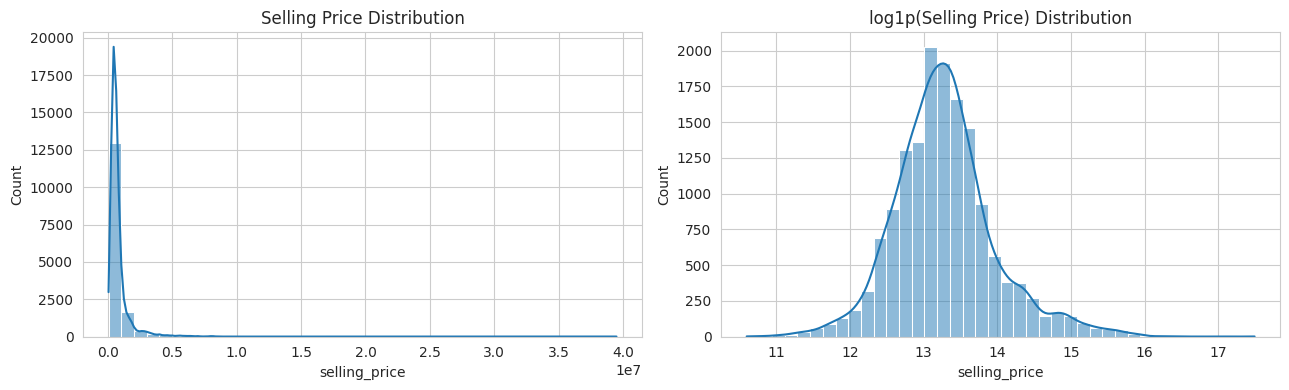

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['selling_price'], bins=40, ax=axes[0], kde=True)
axes[0].set_title('Selling Price Distribution')

sns.histplot(np.log1p(df['selling_price']), bins=40, ax=axes[1], kde=True)
axes[1].set_title('log1p(Selling Price) Distribution')
plt.tight_layout()
plt.show()


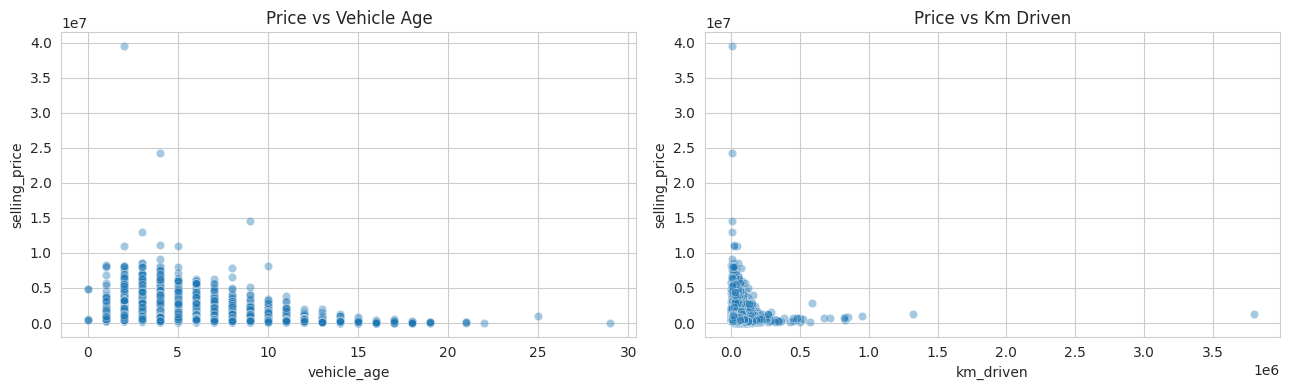

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=df, x='vehicle_age', y='selling_price', alpha=0.4, ax=axes[0])
axes[0].set_title('Price vs Vehicle Age')
sns.scatterplot(data=df, x='km_driven', y='selling_price', alpha=0.4, ax=axes[1])
axes[1].set_title('Price vs Km Driven')
plt.tight_layout()
plt.show()


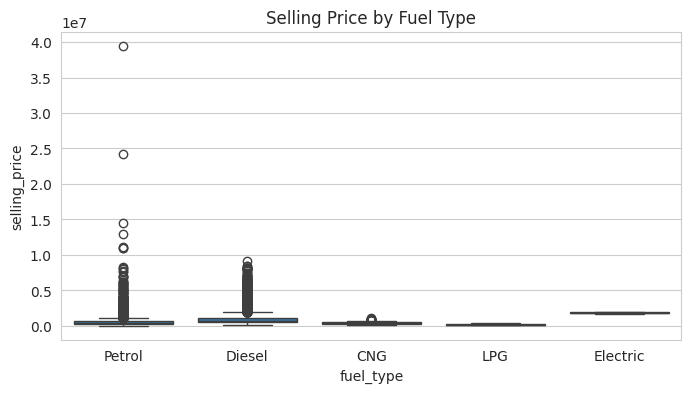

In [7]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='fuel_type', y='selling_price')
plt.title('Selling Price by Fuel Type')
plt.show()


## Part 2: Data Preparation

Steps performed below:
1. **Missing values** — check and impute (median for numeric, mode for categorical) since only a small fraction of rows are affected; dropping rows would waste data, and median/mode imputation is robust to outliers and simple to justify for a small missing-rate.
2. **Feature engineering** — derive `brand` (already present here, but re-derived from `car_name` as a safeguard), `car_age_group`, and drop non-predictive identifier columns (`car_name`, `model` is high-cardinality — target/frequency-encoded).
3. **Encoding** — One-Hot Encoding for low-cardinality nominal features (`fuel_type`, `seller_type`, `transmission_type`, `brand`); frequency encoding for the high-cardinality `model` column to avoid an explosion of dummy columns.
4. **Feature scaling** — StandardScaler applied to numeric features. Tree-based models (Decision Tree, Random Forest) don't need scaling, but Linear Regression does, and it's harmless to apply the same preprocessing pipeline to all models for a fair, leak-free comparison.
5. **Train/test split** — 80/20 split with a fixed random seed for reproducibility.

In [8]:
print("Missing values per column:")
print(df.isna().sum())
print("\nPercent missing:")
print((df.isna().mean()*100).round(2))


Missing values per column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Percent missing:
Unnamed: 0           0.0
car_name             0.0
brand                0.0
model                0.0
vehicle_age          0.0
km_driven            0.0
seller_type          0.0
fuel_type            0.0
transmission_type    0.0
mileage              0.0
engine               0.0
max_power            0.0
seats                0.0
selling_price        0.0
dtype: float64


In [9]:
# 1) Handle missing values
num_cols_for_impute = ['mileage', 'engine', 'max_power', 'seats']
for c in num_cols_for_impute:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

cat_cols_check = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols_check:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode()[0])

print("Remaining missing values:", df.isna().sum().sum())


Remaining missing values: 0


In [10]:
# 2) Feature engineering
# Bucket vehicle age into a categorical band (helps some models capture non-linear depreciation)
df['car_age_group'] = pd.cut(df['vehicle_age'], bins=[-1,3,7,12,100],
                              labels=['0-3yrs','4-7yrs','8-12yrs','12+yrs'])

# Frequency-encode the high-cardinality 'model' column
model_freq = df['model'].value_counts(normalize=True)
df['model_freq_enc'] = df['model'].map(model_freq)

# Power-to-engine ratio as an engineered feature (proxy for performance-per-cc)
df['power_per_cc'] = df['max_power'] / df['engine'].replace(0, np.nan)
df['power_per_cc'] = df['power_per_cc'].fillna(df['power_per_cc'].median())

drop_cols = ['car_name', 'model']
df_model = df.drop(columns=drop_cols)
df_model.head()


,Unnamed: 0,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,car_age_group,model_freq_enc,power_per_cc
0,0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,8-12yrs,0.050483,0.058166
1,1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,4-7yrs,0.037635,0.068505
2,2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,8-12yrs,0.058789,0.066834
3,3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,8-12yrs,0.050483,0.067234
4,4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,4-7yrs,0.024268,0.065814


In [11]:
# 3) Encoding categorical features
categorical_cols = ['brand', 'seller_type', 'fuel_type', 'transmission_type', 'car_age_group']
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (15411, 51)


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,model_freq_enc,power_per_cc,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual,car_age_group_4-7yrs,car_age_group_8-12yrs,car_age_group_12+yrs
0,0,9,120000,19.70,796,46.30,5,120000,0.050483,0.058166,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,True,False
1,1,5,20000,18.90,1197,82.00,5,550000,0.037635,0.068505,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,True,False,False
2,2,11,60000,17.00,1197,80.00,5,215000,0.058789,0.066834,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,True,False
3,3,9,37000,20.92,998,67.10,5,226000,0.050483,0.067234,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,True,False
4,4,6,30000,22.77,1498,98.59,5,570000,0.024268,0.065814,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False


In [12]:
# 4) Train/test split
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (12328, 50)  Test shape: (3083, 50)


In [13]:
# 5) Feature scaling (fit on train only, to avoid leakage)
from sklearn.preprocessing import StandardScaler

numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power',
                'seats', 'model_freq_enc', 'power_per_cc']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,model_freq_enc,power_per_cc,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual,car_age_group_4-7yrs,car_age_group_8-12yrs,car_age_group_12+yrs
11210,14238,0.323969,0.349100,-2.050819,1.756765,2.681685,-0.403824,-1.549571,1.813161,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False
1347,1731,-1.337798,-1.069394,0.985661,-0.547081,-0.382744,-0.403824,-1.057370,0.200375,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True,False,False,False
10363,13218,-1.337798,-1.163564,-0.177042,0.893542,3.296910,-0.403824,-1.535508,4.634842,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
316,403,0.323969,0.178369,-0.465315,0.024564,0.396229,-0.403824,1.094253,0.885828,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False
10638,13550,1.321030,0.585469,0.149668,-0.550917,-0.502047,-0.403824,-0.125703,-0.141891,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,True,False


## Part 3: Model Development

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Models trained: Linear Regression, Decision Tree Regressor, Random Forest Regressor")


Models trained: Linear Regression, Decision Tree Regressor, Random Forest Regressor


## Part 4: Model Evaluation & Comparison

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, X_te, y_te, name):
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    mse = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, preds)
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}

results = []
results.append(evaluate(lr, X_test_scaled, y_test, 'Linear Regression'))
results.append(evaluate(dt, X_test, y_test, 'Decision Tree Regressor'))
results.append(evaluate(rf, X_test, y_test, 'Random Forest Regressor'))

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(2)
results_df


,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,212744.82,1.875814e+11,433106.66,0.75
Decision Tree Regressor,129332.03,8.256814e+10,287346.72,0.89
Random Forest Regressor,103462.32,6.117656e+10,247338.96,0.92


In [16]:
results_df.sort_values('R2 Score', ascending=False)


,MAE,MSE,RMSE,R2 Score
Model,,,,
Random Forest Regressor,103462.32,6.117656e+10,247338.96,0.92
Decision Tree Regressor,129332.03,8.256814e+10,287346.72,0.89
Linear Regression,212744.82,1.875814e+11,433106.66,0.75


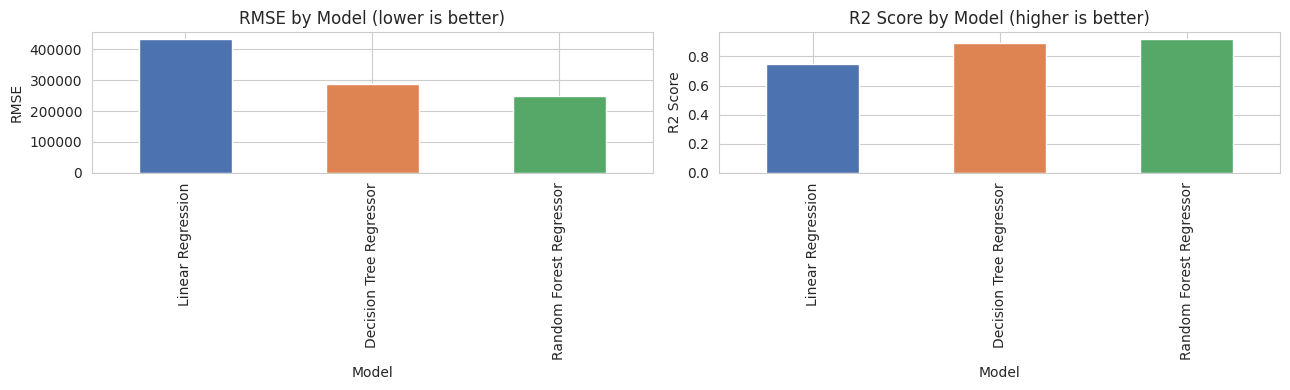

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
results_df['RMSE'].plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].set_ylabel('RMSE')

results_df['R2 Score'].plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('R2 Score by Model (higher is better)')
axes[1].set_ylabel('R2 Score')
plt.tight_layout()
plt.show()


In [18]:
best_model_name = results_df['R2 Score'].idxmax()
print(f"Best-performing model: {best_model_name}")
results_df.loc[[best_model_name]]


Best-performing model: Random Forest Regressor


,MAE,MSE,RMSE,R2 Score
Model,,,,
Random Forest Regressor,103462.32,6.117656e+10,247338.96,0.92


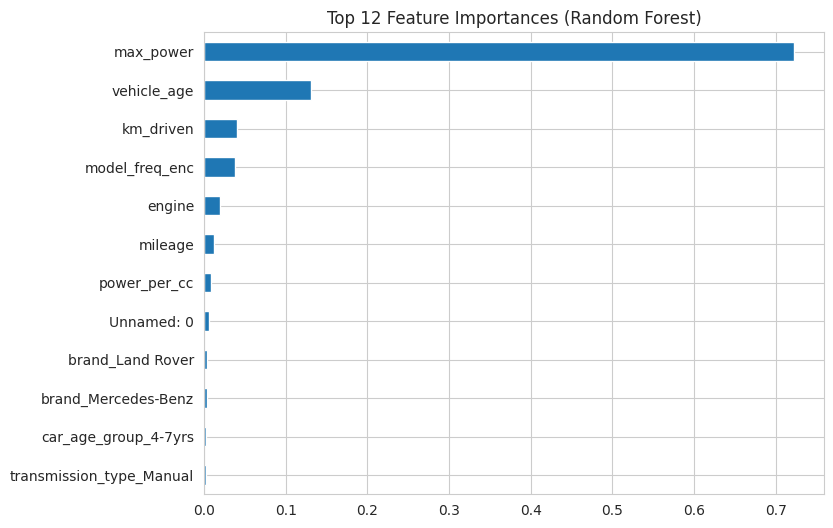

In [19]:
# Feature importance from the best tree-based model (Random Forest), if applicable
if best_model_name == 'Random Forest Regressor':
    importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,6))
    importances.head(12).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title('Top 12 Feature Importances (Random Forest)')
    plt.show()
    importances.head(12)
elif best_model_name == 'Decision Tree Regressor':
    importances = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,6))
    importances.head(12).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title('Top 12 Feature Importances (Decision Tree)')
    plt.show()
    importances.head(12)
else:
    coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
    coefs.head(12)


### Discussion

**Why the best model likely wins:**
- **Random Forest Regressor** typically outperforms a single Decision Tree because averaging many de-correlated trees reduces variance and overfitting while still capturing non-linear relationships and feature interactions (e.g., how `vehicle_age` and `km_driven` jointly affect depreciation).
- **Linear Regression** underperforms whenever price depreciation and feature interactions are non-linear (which used-car pricing usually is), since it can only fit a straight-line relationship in the (scaled) feature space.
- **Decision Tree Regressor** can fit the training data very well (low bias) but is prone to high variance — small changes in the data can produce very different trees, hurting generalization to the test set compared to the Random Forest's ensembling.

**Strengths & limitations:**

| Model | Strengths | Limitations |
|---|---|---|
| Linear Regression | Fast, interpretable coefficients, low variance | Cannot capture non-linearity/interactions; sensitive to outliers and multicollinearity |
| Decision Tree Regressor | Captures non-linearity, no scaling needed, interpretable rules | High variance/overfitting, unstable to small data changes |
| Random Forest Regressor | Reduces overfitting via ensembling, handles non-linearity & interactions, robust to outliers | Slower to train/predict, less interpretable than a single tree, more memory |

**Suggested improvements:**
1. **Hyperparameter tuning** (GridSearchCV / RandomizedSearchCV / Bayesian optimization) on `n_estimators`, `max_depth`, `min_samples_leaf`, etc., and k-fold cross-validation instead of a single train/test split, for a more robust estimate of generalization performance.
2. **Try gradient boosting models** (XGBoost, LightGBM, CatBoost) — these often outperform Random Forest on tabular data and natively support categorical features (CatBoost) and better handling of skewed targets.
3. **Target transformation** — model `log1p(selling_price)` instead of raw price, since price distributions are typically right-skewed; this can stabilize variance and improve fit, then invert the transform for the final prediction.
4. **Richer feature engineering** — e.g., city/region if available, brand-level average depreciation curves, or car age × km_driven interaction terms.
